# data collection

use arxiv api to gether paper that we need


https://info.arxiv.org/help/api/user-manual.html

In [1]:
import os
import arxiv
import requests
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from tex_tool import TexExtractor


## configuration

In [24]:
MAX_RESULTS = 500
CATEGORY = "cat:cs.DC"
TIME_LIMITATION = "submittedDate:[202401010000 TO 202512312359]"
BASE_DIR = "files"
SAVE_DIR = f"{BASE_DIR}/downloads"
EXTRACT_DIR = f"{BASE_DIR}/extract"
ORIGINAL_DATA = f"{BASE_DIR}/arxiv_tex_dataset.xlsx"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

## main

In [27]:
def main():
    client = arxiv.Client()

    search = arxiv.Search(
        query=f"{CATEGORY} and {TIME_LIMITATION}",
        max_results=MAX_RESULTS,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    print("🔍 Fetching paper list from arXiv...")
    results = list(client.results(search))

    print(f"📄 Total fetched: {len(results)}")

    data = []

    pbar = tqdm(results, total=len(results), desc="Processing papers")

    for idx, paper in enumerate(pbar):
        arxiv_id = paper.entry_id.split("/")[-1]

        # 👉 更新进度条信息（不要 print）
        pbar.set_postfix({
            "index": f"{idx+1}/{len(results)}",
            "id": arxiv_id
        })

        file_path = os.path.join(SAVE_DIR, f"{arxiv_id}.tar.gz")

        # =====================
        # 下载（带缓存）
        # =====================
        file_exist = True
        if not os.path.exists(file_path):
            url = paper.entry_id.replace("abs", "e-print")
            try:
                r = requests.get(url, timeout=20)
                if r.status_code == 200:
                    with open(file_path, "wb") as f:
                        f.write(r.content)
                else:
                    file_exist = False
            except:
                file_exist = False

        # =====================
        # 处理 tex
        # =====================
        extractor = TexExtractor(file_path)
        tex_clean = extractor.get_merged_tex()
        data_bytes = tex_clean.encode("utf-8", errors="ignore")
        size = len(data_bytes)

        data.append({
            "id": arxiv_id,
            "title": paper.title,
            "authors": [author.name for author in paper.authors],
            "year": paper.published.year,
            "file_exist": file_exist,
            "tex_size_clean": size
        })

        # 👉 可选：每10篇自动保存一次（防崩）
        if idx % 10 == 0 and len(data) > 0:
            pd.DataFrame(data).to_excel(f"{BASE_DIR}/backup.xlsx", index=False)

        time.sleep(0.3)

    df = pd.DataFrame(data)

    print(f"\n✅ Valid papers: {len(df)}")

    df.to_excel(ORIGINAL_DATA, index=False)

    print("📁 Saved to arxiv_tex_dataset.xlsx")

## run

In [28]:
main()

🔍 Fetching paper list from arXiv...
📄 Total fetched: 500


Processing papers: 100%|██████████| 500/500 [37:21<00:00,  4.48s/it, index=500/500, id=2603.03592v1]  


✅ Valid papers: 500
📁 Saved to arxiv_tex_dataset.xlsx


In [11]:
def get_df(file):
    df = pd.read_excel(file)
    return df.sort_values("tex_size_clean")
origin_df = get_df(ORIGINAL_DATA)

# distribution

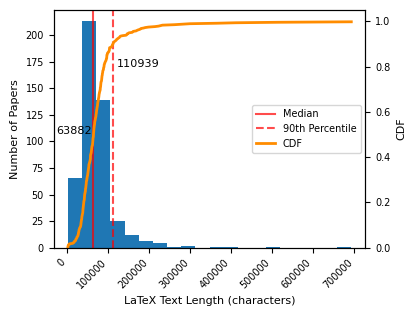

In [12]:

def combined_plot(df):
    sizes = df["tex_size_clean"]
    sorted_sizes = np.sort(sizes)
    cdf = np.arange(len(sorted_sizes)) / len(sorted_sizes)
    
    # 创建图形和主坐标轴
    fig, ax1 = plt.subplots(figsize=(4.2, 3.2))
    
    # 左y轴：直方图
    n, bins, patches = ax1.hist(sizes, bins=20)
    ax1.set_xlabel("LaTeX Text Length (characters)")
    ax1.set_ylabel("Number of Papers")
    ax1.tick_params(axis='y')
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # 右y轴：CDF
    ax2 = ax1.twinx()
    ax2.plot(sorted_sizes, cdf, color='darkorange', linewidth=2, label='CDF')
    ax2.set_ylabel("CDF")
    ax2.tick_params(axis='y')
    ax2.set_ylim(0, 1.05)
    
    # 添加中位数和90%分位数
    median = np.median(sizes)
    p90 = np.percentile(sizes, 90)
    
    # 在直方图区域添加竖线
    ax1.axvline(median, linestyle='-', label='Median', color='red', alpha=0.7)
    ax1.axvline(p90, linestyle='--', label='90th Percentile', color='red', alpha=0.7)
    
    # 添加文本标注（调整位置避免重叠）
    ax1.text(median-90000, max(n)*0.5, f"{median:.0f}")
    ax1.text(p90+10000, max(n)*0.8, f"{p90:.0f}", 
             fontsize=8)
    
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.tight_layout()
    plt.show()
combined_plot(origin_df)